In [1]:
!pip install SimpleITK

import os
import pandas as pd
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("avc0706/luna16")

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/avc0706/luna16...
Path to dataset files: /kaggle/input/datasets/avc0706/luna16


In [8]:
import os
import glob
import pandas as pd
print(" Contents of the root directory ")
for item in os.listdir(path):
    print(f"- {item}")
print("\n Searching for annotations.csv")
csv_files = glob.glob(os.path.join(path, '**', 'annotations.csv'), recursive=True)

if len(csv_files) > 0:
    csv_path = csv_files[0]
    print(f"Found annotations file at: {csv_path}")
    

    annotations_df = pd.read_csv(csv_path)
    print(f"Total annotated nodules: {len(annotations_df)}")
    display(annotations_df.head())
else:
    print("Can find this file")

# 3. Find and count all .mhd files (CT scan images)
print(" Searching for CT scan (.mhd) files ")
mhd_files = glob.glob(os.path.join(path, '**', '*.mhd'), recursive=True)

print(f"Total .mhd files found: {len(mhd_files)}")
if len(mhd_files) > 0:
    print("Example paths of the first 3 files:")
    for f in mhd_files[:3]:
        print(f" - {f}")

 Contents of the root directory 
- subset2
- subset1
- subset4
- subset3
- seg-lungs-LUNA16
- sampleSubmission.csv
- subset0
- annotations.csv
- candidates_V2
- evaluationScript
- candidates.csv

 Searching for annotations.csv
Found annotations file at: /kaggle/input/datasets/avc0706/luna16/annotations.csv
Total annotated nodules: 1186


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


 Searching for CT scan (.mhd) files 
Total .mhd files found: 1333
Example paths of the first 3 files:
 - /kaggle/input/datasets/avc0706/luna16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.311236942972970815890902714604.mhd
 - /kaggle/input/datasets/avc0706/luna16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.212346425055214308006918165305.mhd
 - /kaggle/input/datasets/avc0706/luna16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.281967919138248195763602360723.mhd


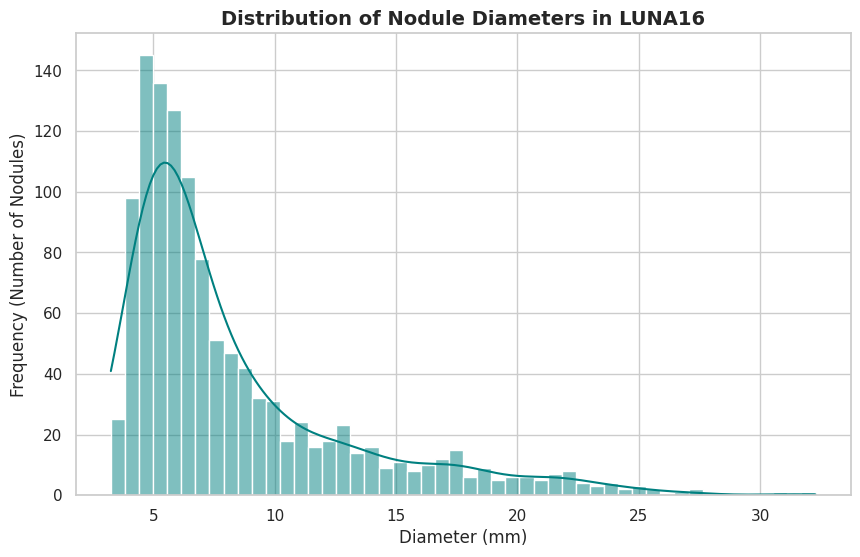

 Summary statistics of nodule diameters (mm)
count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(annotations_df['diameter_mm'], bins=50, kde=True, color='teal')

plt.title('Distribution of Nodule Diameters in LUNA16', fontsize=14, fontweight='bold')
plt.xlabel('Diameter (mm)', fontsize=12)
plt.ylabel('Frequency (Number of Nodules)', fontsize=12)
plt.show()

print(" Summary statistics of nodule diameters (mm)")
print(annotations_df['diameter_mm'].describe())




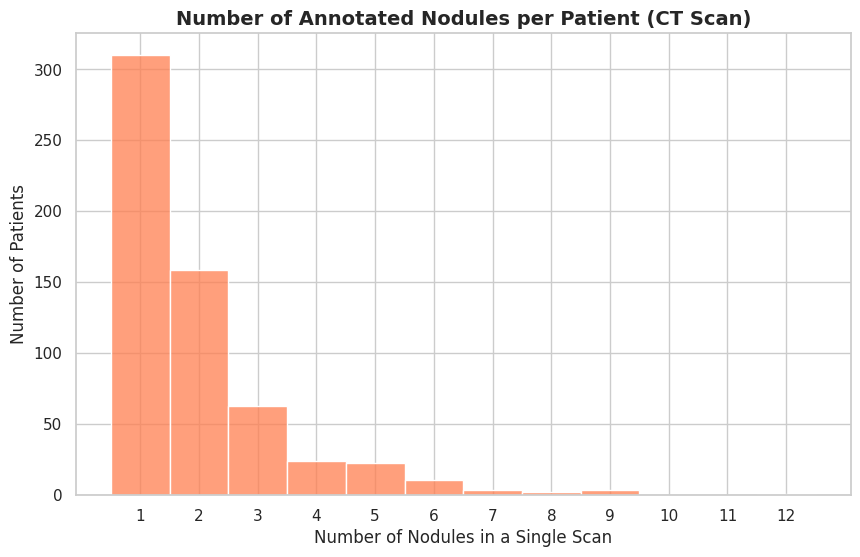


 Insights on Nodules per Patient
Maximum nodules in a single patient: 12
Average nodules per patient: 1.97
Total unique patients with annotated nodules: 601


In [10]:

#  Number of Nodules per Patient (CT Scan)
nodules_per_patient = annotations_df['seriesuid'].value_counts()

plt.figure(figsize=(10, 6))
# Plot the distribution of nodule counts
sns.histplot(nodules_per_patient, bins=range(1, nodules_per_patient.max() + 2), discrete=True, color='coral')

plt.title('Number of Annotated Nodules per Patient (CT Scan)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Nodules in a Single Scan', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.xticks(range(1, nodules_per_patient.max() + 1))
plt.show()

# Print insights
print("\n Insights on Nodules per Patient")
print(f"Maximum nodules in a single patient: {nodules_per_patient.max()}")
print(f"Average nodules per patient: {nodules_per_patient.mean():.2f}")
print(f"Total unique patients with annotated nodules: {len(nodules_per_patient)}")

Loading CT scan: /kaggle/input/datasets/avc0706/luna16/subset2/subset2/1.3.6.1.4.1.14519.5.2.1.6279.6001.311236942972970815890902714604.mhd
Full 3D Scan Shape (Z_slices, Y_height, X_width): (461, 512, 512)


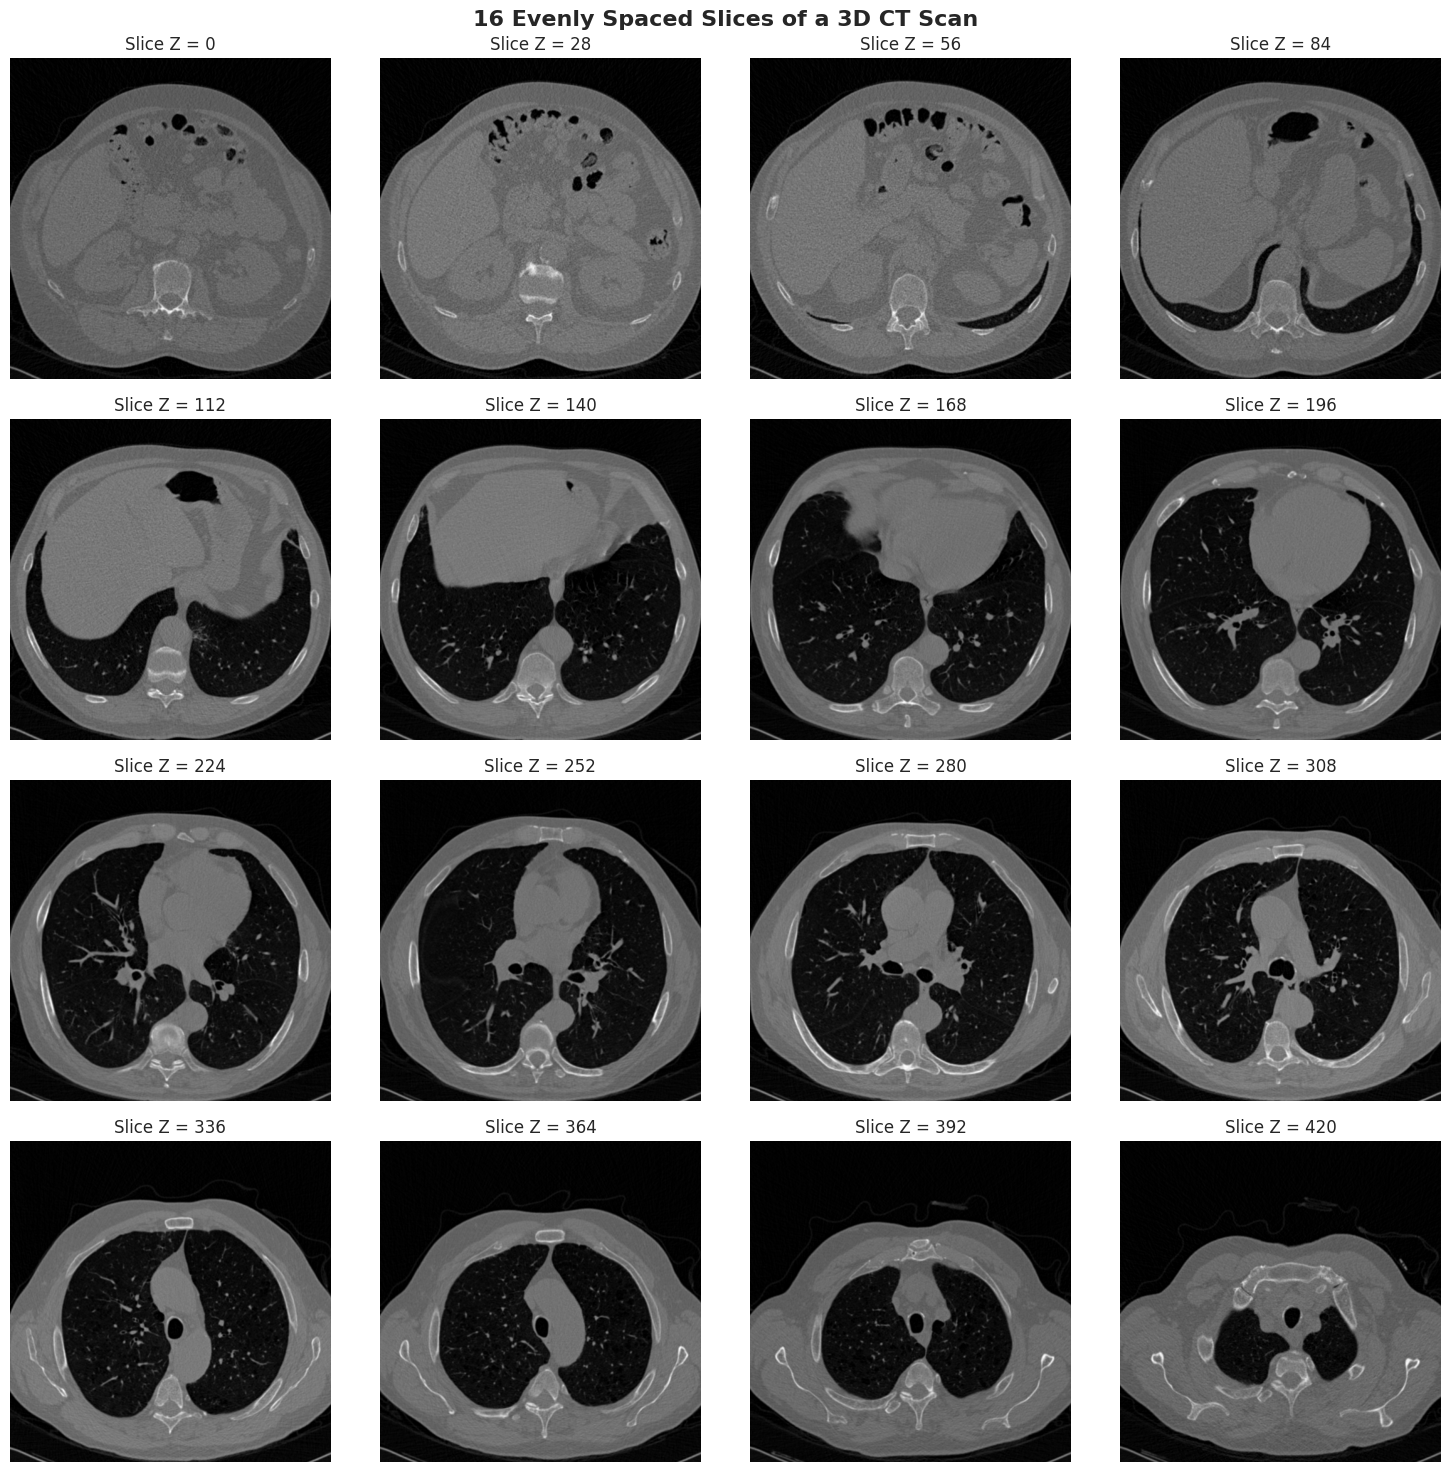

In [18]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

if len(mhd_files) > 0:
    sample_scan_path = mhd_files[0]
    print(f"Loading CT scan: {sample_scan_path}")
    itk_image = sitk.ReadImage(sample_scan_path)
    scan_array = sitk.GetArrayFromImage(itk_image)
    print(f"Full 3D Scan Shape (Z_slices, Y_height, X_width): {scan_array.shape}")
    z_dim = scan_array.shape[0]
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    step = max(1, z_dim // 16) 
    for i, ax in enumerate(axes.flat):
        slice_idx = i * step
        
        if slice_idx < z_dim:
            # Extract the 2D slice at the current Z index
            # This represents the Axial plane (viewing from top/bottom)
            slice_2d = scan_array[slice_idx, :, :]
            
            # Display using grayscale colormap standard for medical images
            ax.imshow(slice_2d, cmap='gray')
            ax.set_title(f"Slice Z = {slice_idx}")
            ax.axis('off')
        else:
            ax.axis('off') # Hide unused subplots

    plt.suptitle("16 Evenly Spaced Slices of a 3D CT Scan", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No .mhd files ")

In [20]:
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt

def load_itk_image(filename):
    """Reads .mhd file and returns 3D array (Z, Y, X), origin, and spacing."""
    itkimage = sitk.ReadImage(filename)
    image_array = sitk.GetArrayFromImage(itkimage) 
    origin = np.array(itkimage.GetOrigin())
    spacing = np.array(itkimage.GetSpacing())
    return image_array, origin, spacing


In [21]:

def world_to_voxel(world_coords, origin, spacing):
    """Converts real-world mm coordinates to voxel matrix indices."""
    voxel_coords = np.absolute(world_coords - origin) / spacing
    voxel_coords = [int(np.round(c)) for c in voxel_coords]
    return tuple(voxel_coords)


In [22]:
def extract_3d_patch(image_array, center_z, center_y, center_x, patch_size=32):
    """Extracts a 32x32x32 patch around the nodule center."""
    half_size = patch_size // 2
    
    # Calculate bounding box coordinates
    z_min, z_max = max(0, center_z - half_size), center_z + half_size
    y_min, y_max = max(0, center_y - half_size), center_y + half_size
    x_min, x_max = max(0, center_x - half_size), center_x + half_size
    
    patch = image_array[z_min:z_max, y_min:y_max, x_min:x_max]
    
    # Pad with air value (-1000 HU) if the nodule is near the image edge
    if patch.shape != (patch_size, patch_size, patch_size):
        pad_z = (0, patch_size - patch.shape[0])
        pad_y = (0, patch_size - patch.shape[1])
        pad_x = (0, patch_size - patch.shape[2])
        patch = np.pad(patch, (pad_z, pad_y, pad_x), mode='constant', constant_values=-1000) 
        
    return patch



In [23]:

print("Searching for a valid nodule in the downloaded data...")
sample_row = None
sample_mhd_path = None

for index, row in annotations_df.iterrows():
    uid = row['seriesuid']
    matching_files = [f for f in mhd_files if uid in f]
    if matching_files:
        sample_row = row
        sample_mhd_path = matching_files[0]
        break

if sample_mhd_path:
    print(f"Found a match! Testing on Patient UID: {sample_row['seriesuid']}")
else:
    print("No matching files found.")

Searching for a valid nodule in the downloaded data...
Found a match! Testing on Patient UID: 1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222365663678666836860


World Coordinates (mm): [-128.6994211 -175.3192718 -298.3875064]
Voxel Indices (X, Y, Z): (45, 212, 78)
Extracted Patch Shape: (32, 32, 32)


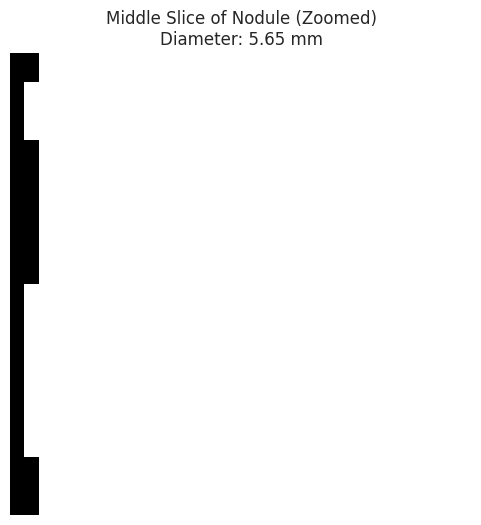

In [24]:
if sample_mhd_path:

    img_array, origin, spacing = load_itk_image(sample_mhd_path)
    world_coord = np.array([sample_row['coordX'], sample_row['coordY'], sample_row['coordZ']])
    voxel_x, voxel_y, voxel_z = world_to_voxel(world_coord, origin, spacing)
    
    print(f"World Coordinates (mm): {world_coord}")
    print(f"Voxel Indices (X, Y, Z): ({voxel_x}, {voxel_y}, {voxel_z})")
    
    # Step C: Extract 3D Patch
    patch_3d = extract_3d_patch(img_array, voxel_z, voxel_y, voxel_x, patch_size=32)
    print(f"Extracted Patch Shape: {patch_3d.shape}")
    
    # Step D: Visualize the center slice
    plt.figure(figsize=(6, 6))
    middle_slice = patch_3d[16, :, :] # Index 16 is the center of a 32-depth patch
    
    plt.imshow(middle_slice, cmap='gray')
    plt.title(f"Middle Slice of Nodule (Zoomed)\nDiameter: {sample_row['diameter_mm']:.2f} mm")
    plt.axis('off')
    plt.show()

In [ ]:
#Train

In [25]:
from sklearn.model_selection import train_test_split

unique_patients = annotations_df['seriesuid'].unique()
print(f"Total unique patients: {len(unique_patients)}")
train_patients, temp_patients = train_test_split(
    unique_patients, 
    test_size=0.30, 
    random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, 
    test_size=0.50, 
    random_state=42
)

print(f"Patient split -> Train: {len(train_patients)}, Val: {len(val_patients)}, Test: {len(test_patients)}")

Total unique patients: 601
Patient split -> Train: 420, Val: 90, Test: 91


In [26]:
import pandas as pd
train_df = annotations_df[annotations_df['seriesuid'].isin(train_patients)].reset_index(drop=True)
val_df = annotations_df[annotations_df['seriesuid'].isin(val_patients)].reset_index(drop=True)
test_df = annotations_df[annotations_df['seriesuid'].isin(test_patients)].reset_index(drop=True)

print("=== Nodule Distribution across splits ===")
print(f"Train nodules: {len(train_df)} ({len(train_df)/len(annotations_df)*100:.1f}%)")
print(f"Validation nodules: {len(val_df)} ({len(val_df)/len(annotations_df)*100:.1f}%)")
print(f"Test nodules: {len(test_df)} ({len(test_df)/len(annotations_df)*100:.1f}%)")

train_df.to_csv("train_annotations.csv", index=False)
val_df.to_csv("val_annotations.csv", index=False)
test_df.to_csv("test_annotations.csv", index=False)
print("\nSaved split dataframes to CSV files.")

=== Nodule Distribution across splits ===
Train nodules: 819 (69.1%)
Validation nodules: 166 (14.0%)
Test nodules: 201 (16.9%)

Saved split dataframes to CSV files.


In [27]:
uid_to_path = {}

for filepath in mhd_files:
    # Extract the seriesuid from the filename (assuming the filename contains it)
    # LUNA16 filenames are typically the seriesuid itself
    filename = filepath.split('/')[-1].replace('.mhd', '')
    uid_to_path[filename] = filepath

print(f" Created mapping for {len(uid_to_path)} CT scans.")

 Created mapping for 888 CT scans.


In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

candidate_files = glob.glob(os.path.join(path, '**', 'candidates*.csv'), recursive=True)
if not candidate_files:
    print("Could not find ")
else:
    candidates_df = pd.read_csv(candidate_files[0])
    print(f"Total number of candidates: {len(candidates_df)}")
    positives = candidates_df[candidates_df['class'] == 1]
    negatives = candidates_df[candidates_df['class'] == 0]
    sampled_negatives = negatives.sample(n=len(positives), random_state=42)

  
    balanced_df = pd.concat([positives, sampled_negatives]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"Balanced dataset has: {len(balanced_df)} samples (Ratio 1:1)")

    #Split Train/Val/Test by Patient ID 
    unique_patients = balanced_df['seriesuid'].unique()
    train_patients, temp_patients = train_test_split(unique_patients, test_size=0.3, random_state=42)
    val_patients, test_patients = train_test_split(temp_patients, test_size=0.5, random_state=42)

    train_df = balanced_df[balanced_df['seriesuid'].isin(train_patients)].reset_index(drop=True)
    val_df = balanced_df[balanced_df['seriesuid'].isin(val_patients)].reset_index(drop=True)
    test_df = balanced_df[balanced_df['seriesuid'].isin(test_patients)].reset_index(drop=True)
    
    print("Train/Val/Test split completed with both labels 0 and 1!")


Total number of candidates: 551065
Balanced dataset has: 2702 samples (Ratio 1:1)
Train/Val/Test split completed with both labels 0 and 1!


In [45]:
import torch

class LUNADataset(Dataset):
    def __init__(self, df, uid_to_path_dict, patch_size=32):
        self.df = df
        self.uid_to_path = uid_to_path_dict
        self.patch_size = patch_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        uid = row['seriesuid']
        
        if uid not in self.uid_to_path:
            return torch.zeros((1, self.patch_size, self.patch_size, self.patch_size)), torch.tensor(-1.0)
            
        filepath = self.uid_to_path[uid]
        img_array, origin, spacing = load_itk_image(filepath)
        
        world_coord = np.array([row['coordX'], row['coordY'], row['coordZ']])
        voxel_x, voxel_y, voxel_z = world_to_voxel(world_coord, origin, spacing)
        
        patch_3d = extract_3d_patch(img_array, voxel_z, voxel_y, voxel_x, patch_size=self.patch_size)
        patch_tensor = torch.tensor(patch_3d, dtype=torch.float32).unsqueeze(0)
        
        label = float(row['class'])
        label_tensor = torch.tensor([label], dtype=torch.float32)
            
        return patch_tensor, label_tensor

#  DataLoaders
train_dataset = LUNADataset(train_df, uid_to_path, patch_size=32)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)




In [46]:

train_dataset = LUNADataset(train_df, uid_to_path, patch_size=32)
val_dataset = LUNADataset(val_df, uid_to_path, patch_size=32)
test_dataset = LUNADataset(test_df, uid_to_path, patch_size=32)
BATCH_SIZE = 4 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DaTA is okay")
print(f"Number of batches in Train DataLoader: {len(train_loader)}")

DaTA is okay
Number of batches in Train DataLoader: 470


In [47]:
# Fetch one batch of data to test
for patches, labels in train_loader:
    # Filter out missing files (if any returned -1 label)
    valid_idx = (labels.squeeze() != -1)
    patches = patches[valid_idx]
    labels = labels[valid_idx]
    
    if len(patches) > 0:
        print(" Test fetching a batch ")
        print(f"Batch Patches Shape: {patches.shape}") 
        print(f"Expected Shape: (Batch_Size, Channels, Depth, Height, Width) -> ({BATCH_SIZE}, 1, 32, 32, 32)")
        print(f"Batch Labels Shape: {labels.shape}")
        print(f"Labels: {labels.flatten().tolist()}")
        break # Only test the first batch

 Test fetching a batch 
Batch Patches Shape: torch.Size([4, 1, 32, 32, 32])
Expected Shape: (Batch_Size, Channels, Depth, Height, Width) -> (4, 1, 32, 32, 32)
Batch Labels Shape: torch.Size([4, 1])
Labels: [1.0, 1.0, 0.0, 0.0]


In [31]:
#Model

In [49]:
import torch.nn as nn

# 1. Define the 3D CNN Architecture
class NoduleDetector3D(nn.Module):
    def __init__(self):
        super(NoduleDetector3D, self).__init__()
        
        # Block 1: Input (Batch, 1, 32, 32, 32)
        self.conv1 = nn.Sequential(
            nn.Conv3d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2, stride=2) # Output: (Batch, 16, 16, 16, 16)
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv3d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2, stride=2) # Output: (Batch, 32, 8, 8, 8)
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv3d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d(kernel_size=2, stride=2) # Output: (Batch, 64, 4, 4, 4)
        )
        
        # Fully Connected Layers
        # Flatten size = 64 channels * 4 * 4 * 4 = 4096 features
        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5), # Prevent overfitting
            nn.Linear(128, 1),
            nn.Sigmoid()       # Output a probability between 0 and 1
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x) # Đã bổ sung
        x = self.conv3(x) # Đã bổ sung
        x = x.view(x.size(0), -1) # Flatten the 3D tensor to 1D
        x = self.fc(x)
        return x



In [50]:
import torch.optim as optim

# 1. Select the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Instantiate the model and move it to the selected device
model = NoduleDetector3D().to(device)

# 3. Define the Loss Function (Binary Cross Entropy)
criterion = nn.BCELoss()

# 4. Define the Optimizer (Adam is usually a safe and good choice)
optimizer = optim.Adam(model.parameters(), lr=1e-4)


Using device: cpu


In [51]:

num_epochs = 5
print("Starting training process...")

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    running_loss = 0.0
    
    # 2. Iterate over the training DataLoader
    for batch_idx, (patches, labels) in enumerate(train_loader):
        # Filter out invalid patches (labeled as -1 from our Dataset logic)
        valid_idx = (labels.squeeze() != -1)
        patches = patches[valid_idx]
        labels = labels[valid_idx]
        
        # Skip if the batch becomes empty after filtering
        if len(patches) == 0:
            continue
            
        # Move data to GPU/CPU
        patches = patches.to(device)
        labels = labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass: predict probabilities
        outputs = model(patches)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass: compute gradients
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        running_loss += loss.item()
        
        # Print progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            
    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    print(f"=== Epoch [{epoch+1}/{num_epochs}] completed. Average Loss: {epoch_loss:.4f} ===")


Starting training process...
Epoch [1/5], Batch [10/470], Loss: 0.8430
Epoch [1/5], Batch [20/470], Loss: 1.4256
Epoch [1/5], Batch [30/470], Loss: 1.1787
Epoch [1/5], Batch [40/470], Loss: 0.6396
Epoch [1/5], Batch [50/470], Loss: 0.7050
Epoch [1/5], Batch [60/470], Loss: 0.6503
Epoch [1/5], Batch [70/470], Loss: 1.0514
Epoch [1/5], Batch [80/470], Loss: 0.7087
Epoch [1/5], Batch [90/470], Loss: 0.5003
Epoch [1/5], Batch [100/470], Loss: 0.7039
Epoch [1/5], Batch [110/470], Loss: 0.6264
Epoch [1/5], Batch [120/470], Loss: 0.6617
Epoch [1/5], Batch [130/470], Loss: 0.7422
Epoch [1/5], Batch [140/470], Loss: 0.7217
Epoch [1/5], Batch [150/470], Loss: 0.8597
Epoch [1/5], Batch [160/470], Loss: 0.7185
Epoch [1/5], Batch [170/470], Loss: 0.6945
Epoch [1/5], Batch [180/470], Loss: 0.6994
Epoch [1/5], Batch [190/470], Loss: 0.4919
Epoch [1/5], Batch [200/470], Loss: 0.6387
Epoch [1/5], Batch [210/470], Loss: 0.7122
Epoch [1/5], Batch [220/470], Loss: 0.6425
Epoch [1/5], Batch [230/470], Loss

Starting evaluation on the Validation set...

=== VALIDATION RESULTS ===
Overall Accuracy: 51.14%

Detailed Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.52      0.12      0.19       195
Positive (1)       0.51      0.90      0.65       200

    accuracy                           0.51       395
   macro avg       0.52      0.51      0.42       395
weighted avg       0.52      0.51      0.42       395



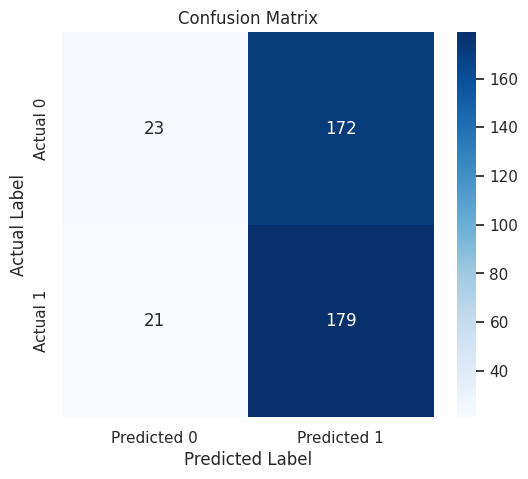

In [54]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize Validation DataLoader with class LUNADataset_V2 (to get dynamic labels)
# Note: val_df was created in the Balanced Dataset splitting step
val_dataset = LUNADataset(val_df, uid_to_path, patch_size=32)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

# 2. Switch model to evaluation mode (disable Dropout and dynamic BatchNorm)
model.eval()

all_preds = []
all_labels = []

print("Starting evaluation on the Validation set...")

# 3. Disable Gradient computation to save RAM and speed up
with torch.no_grad():
    for patches, labels in val_loader:
        valid_idx = (labels.squeeze() != -1)
        patches = patches[valid_idx]
        labels = labels[valid_idx]
        
        if len(patches) == 0:
            continue
            
        patches = patches.to(device)
        labels = labels.to(device).cpu().numpy() # Move true labels back to CPU
        outputs = model(patches)
        
        # since output is Sigmoid, set threshold at 0.5
        # > 0.5 is label 1, <= 0.5 is label 0
        preds = (outputs.cpu().numpy() > 0.5).astype(int)
        
        all_preds.extend(preds)
        all_labels.extend(labels)

# 4. Compute medical evaluation metrics
print("\nVALIDATION RESULTS")
acc = accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy: {acc * 100:.2f}%\n")

print("Detailed Classification Report:")
# Class 0: Negative (Non-nodule), Class 1: Positive (Nodule)
print(classification_report(all_labels, all_preds, target_names=["Negative (0)", "Positive (1)"]))

# 5. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()
